# TripSafe - Data Preprocessing on Python

In [18]:
# Load All Dependencies
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Raw Dataset
raw_dataset = pd.read_csv("US_Accidents.csv")

# Bash processed Dataset
filtered_df = pd.read_csv("CA_Accidents.csv")

# Shape of the Raw Dataset
print(raw_dataset.shape)

# Shape of the Bash processed Dataset
print(filtered_df.shape)

(7728394, 46)
(1708282, 46)


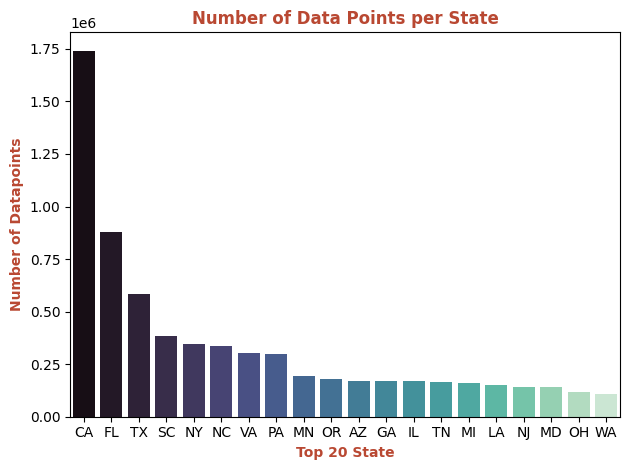

In [20]:
# Plot for Presentation and Report  
state_counts = raw_dataset['State'].value_counts().head(20).reset_index()
state_counts.columns = ['State', 'Count']

# Barplot
sns.barplot(data=state_counts, x='State', y='Count', palette='mako')
plt.title("Number of Data Points per State",fontweight='bold',color='#b94832')
plt.xlabel("Top 20 State",fontweight='bold',color='#b94832')
plt.ylabel("Number of Datapoints",fontweight='bold',color='#b94832')
plt.tight_layout()
plt.show()

# Delete the raw_dataset from memory 
del raw_dataset

## Data Selection

In [21]:
# Print All the Coloumns 
print(filtered_df.columns)

# Pick Relavant Columns, remove coloumns you are 100% sure are useless 
lst =['Source','Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng','Description', 'Airport_Code','Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight',"ID","Country","Street","Timezone","Weather_Timestamp","State"]

# Dropping Irrevelant Columns 
filtered_df = filtered_df.drop(lst, axis =1 )

# Shape and Columns 
print(filtered_df.shape)
filtered_df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')
(1708282, 16)


Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'Zipcode', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition'],
      dtype='object')

## Exploratory Data Analysis

In [22]:
# Analyse 

# Basic Stats
print("Basic Stats")
print(filtered_df.describe())

# Value Counts
print("\n Value Counts")
print(filtered_df.isnull().sum())
      
# Print fist 5 Columns
filtered_df.head(5)

Basic Stats
           Severity  Distance(mi)  Temperature(F)  Wind_Chill(F)  \
count  1.708282e+06  1.708282e+06    1.695464e+06   1.230468e+06   
mean   2.165614e+00  4.821000e-01    6.390045e+01   6.275976e+01   
std    4.061400e-01  1.346038e+00    1.359120e+01   1.459514e+01   
min    1.000000e+00  0.000000e+00   -2.990000e+01  -2.800000e+01   
25%    2.000000e+00  0.000000e+00    5.500000e+01   5.400000e+01   
50%    2.000000e+00  2.400000e-02    6.300000e+01   6.200000e+01   
75%    2.000000e+00  4.330000e-01    7.200000e+01   7.200000e+01   
max    4.000000e+00  2.272100e+02    2.070000e+02   2.070000e+02   

        Humidity(%)  Pressure(in)  Visibility(mi)  Wind_Speed(mph)  \
count  1.693092e+06  1.704306e+06    1.701308e+06     1.578542e+06   
mean   5.871381e+01  2.963127e+01    9.089184e+00     6.550965e+00   
std    2.421471e+01  7.762523e-01    2.521921e+00     5.700134e+00   
min    1.000000e+00  3.000000e-01    0.000000e+00     0.000000e+00   
25%    4.000000e+01  2.96

,Severity,Start_Time,End_Time,Distance(mi),City,County,Zipcode,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition
0,3,2016-06-21 10:34:40,2016-06-21 11:04:40,0.0,Vallejo,Solano,94591,75.0,NaN,48.0,30.00,10.0,Variable,5.8,NaN,Clear
1,3,2016-06-21 10:30:16,2016-06-21 11:16:39,0.0,Hayward,Alameda,94544,75.0,NaN,48.0,30.06,10.0,WSW,4.6,NaN,Clear
2,2,2016-06-21 10:49:14,2016-06-21 11:19:14,0.0,Walnut Creek,Contra Costa,94595,82.9,NaN,31.0,29.97,10.0,NNW,4.6,NaN,Clear
3,3,2016-06-21 10:41:42,2016-06-21 11:11:42,0.0,Cupertino,Santa Clara,95014,75.9,NaN,48.0,30.04,10.0,NNE,4.6,NaN,Clear
4,2,2016-06-21 10:16:26,2016-06-21 11:04:16,0.0,San Jose,Santa Clara,95118,75.2,NaN,41.0,30.06,10.0,Variable,5.8,NaN,Clear


## Data Cleaning

In [23]:
# Remove Duplicates
# Bash Command - tail -n +2 CA_Accidents.csv | sort | uniq -d | wc -l incadate zero duplicated.
# When drop_duplicates used 24598 found and removed
 
pre_removal = filtered_df.shape
print(f"Shape Before Duplicate Removal:{filtered_df.shape}")

filtered_df.drop_duplicates(inplace=True)

print(f"Shape After Duplicate Removal:{filtered_df.shape}")
print(f"Duplicates Removed: {pre_removal[0] -filtered_df.shape[0]} ")

Shape Before Duplicate Removal:(1708282, 16)
Shape After Duplicate Removal:(1683684, 16)
Duplicates Removed: 24598 


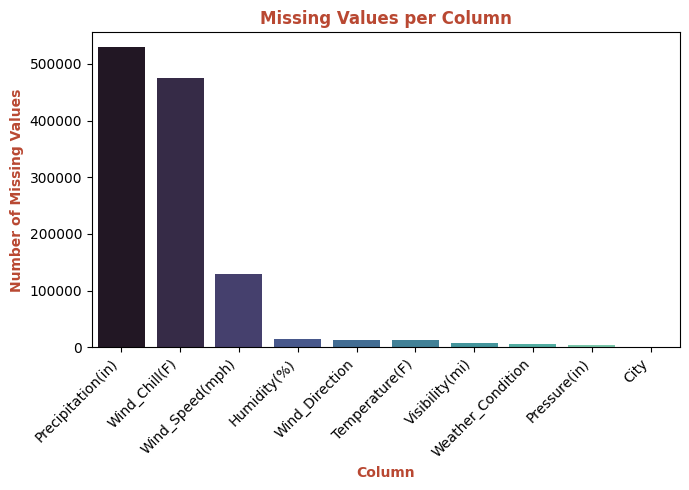

In [24]:
# Plot for Presentation and Report 
# Calculate missing values
missing = filtered_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

# Convert to DataFrame for seaborn
missing_df = missing.reset_index()
missing_df.columns = ['Column', 'Missing Count']

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(data=missing_df, x='Column', y='Missing Count', palette='mako')

plt.title("Missing Values per Column", fontweight='bold', color='#b94832')
plt.xlabel("Column", fontweight='bold', color='#b94832')
plt.ylabel("Number of Missing Values", fontweight='bold', color='#b94832')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# EDA look ups
print(filtered_df.isnull().sum())
print("\n Data Types")
print(filtered_df.dtypes)

Severity                  0
Start_Time                0
End_Time                  0
Distance(mi)              0
City                     11
County                    0
Zipcode                   0
Temperature(F)        12584
Wind_Chill(F)        475056
Humidity(%)           14919
Pressure(in)           3927
Visibility(mi)         6890
Wind_Direction        12955
Wind_Speed(mph)      129072
Precipitation(in)    529034
Weather_Condition      6534
dtype: int64

 Data Types
Severity               int64
Start_Time            object
End_Time              object
Distance(mi)         float64
City                  object
County                object
Zipcode               object
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Direction        object
Wind_Speed(mph)      float64
Precipitation(in)    float64
Weather_Condition     object
dtype: object


In [26]:
# Dealing with Columns with NaN values
# Categorical Columns will be filled with mode
# Numberical Values either with mean or median based of skewness

# Numberical Columns with NaN 
num_columns_with_missing = [
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

for column in  num_columns_with_missing:
    print(f"Column: {column} \n     ")
    print(f"Skewness:{filtered_df[column].skew(): 0.4f}")
    print(f"Mode:{filtered_df[column].mode()[0]}")
    print(filtered_df[column].value_counts().head(5))
    print(f"Number of Unique Values: {filtered_df[column].nunique()}")




Column: Temperature(F) 
     
Skewness: 0.2897
Mode:59.0
Temperature(F)
59.0    59228
57.0    53726
63.0    53621
61.0    52234
64.0    50815
Name: count, dtype: int64
Number of Unique Values: 570
Column: Wind_Chill(F) 
     
Skewness: 0.1400
Mode:57.0
Wind_Chill(F)
57.0    42273
63.0    40823
59.0    40301
61.0    39186
54.0    38768
Name: count, dtype: int64
Number of Unique Values: 402
Column: Humidity(%) 
     
Skewness:-0.2725
Mode:93.0
Humidity(%)
93.0     45795
100.0    45098
83.0     34859
72.0     33146
78.0     32415
Name: count, dtype: int64
Number of Unique Values: 100
Column: Pressure(in) 
     
Skewness:-3.8959
Mode:29.91
Pressure(in)
29.91    36632
29.94    35999
29.88    35700
29.96    35507
29.90    33619
Name: count, dtype: int64
Number of Unique Values: 834
Column: Visibility(mi) 
     
Skewness: 4.8897
Mode:10.0
Visibility(mi)
10.0    1308974
9.0       61957
7.0       58321
8.0       51261
6.0       40813
Name: count, dtype: int64
Number of Unique Values: 63
Column:

In [27]:
# EDA lookups
print(filtered_df.isnull().sum())
print(filtered_df.dtypes)

Severity                  0
Start_Time                0
End_Time                  0
Distance(mi)              0
City                     11
County                    0
Zipcode                   0
Temperature(F)        12584
Wind_Chill(F)        475056
Humidity(%)           14919
Pressure(in)           3927
Visibility(mi)         6890
Wind_Direction        12955
Wind_Speed(mph)      129072
Precipitation(in)    529034
Weather_Condition      6534
dtype: int64
Severity               int64
Start_Time            object
End_Time              object
Distance(mi)         float64
City                  object
County                object
Zipcode               object
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Direction        object
Wind_Speed(mph)      float64
Precipitation(in)    float64
Weather_Condition     object
dtype: object


In [28]:
# Filling NaN categorical data
filtered_df["City"].fillna(filtered_df["City"].mode()[0],inplace = True)
filtered_df["Weather_Condition"].fillna(filtered_df["Weather_Condition"].mode()[0],inplace = True)
filtered_df["Wind_Direction"].fillna(filtered_df["Wind_Direction"].mode()[0],inplace = True)


# Filling Nan Numerical Data
filtered_df["Temperature(F)"].fillna(filtered_df["Temperature(F)"].median(),inplace = True)
filtered_df["Wind_Chill(F)"].fillna(filtered_df["Wind_Chill(F)"].mean(),inplace = True)
filtered_df["Humidity(%)"].fillna(filtered_df["Humidity(%)"].median(),inplace = True)
filtered_df["Pressure(in)"].fillna(filtered_df["Pressure(in)"].median(),inplace = True)
filtered_df["Visibility(mi)"].fillna(filtered_df["Visibility(mi)"].median(),inplace = True)

# Since Our dataset is massive, its better drop rows with these NaN values in these columns
# These columns have 200K+ NaN values.
filtered_df = filtered_df.dropna(subset=[
    "Wind_Chill(F)",
    "Precipitation(in)",
    "Wind_Speed(mph)"
])

# Zipcode has 126942 unique values, which is a lot. While Trainning this can get really noisey, we will grouping them on there first three digits 
# Some zipcode are in the format 95377-4563, we came remove this extra details 
print(f"Zipcode Unique Values Before: {filtered_df['Zipcode'].nunique()}")
filtered_df["Zipcode"] = filtered_df["Zipcode"].astype(str).str.extract(r"(\d{5})")

#When pattens are not found, Zipcode might become 0, remove those. This is not the best way to deal with this. But we have a lot of data and we need to trim it anyway.
filtered_df["Zipcode"].dropna(inplace=True)


print(f"Shape After Removal:{filtered_df.shape}")
print(f"Zipcode Unique Values After:{filtered_df['Zipcode'].nunique()}")

Zipcode Unique Values Before: 105518
Shape After Removal:(1138154, 16)
Zipcode Unique Values After:1545


## Feature Engineering

In [29]:
# Converting to DateTime
filtered_df["Start_Time"] = pd.to_datetime(filtered_df["Start_Time"], errors='coerce')
filtered_df["End_Time"] = pd.to_datetime(filtered_df["End_Time"], errors='coerce')

# Droping NAN rows 
filtered_df = filtered_df.dropna()

# Feature Engineering
filtered_df["Date"] = pd.to_datetime(filtered_df["Start_Time"].dt.date)
filtered_df["day_of_week"] = filtered_df["Start_Time"].dt.dayofweek
filtered_df["Hour"] = filtered_df["Start_Time"].dt.hour
filtered_df["Duration_minutes"] = (filtered_df["End_Time"] - filtered_df["Start_Time"]).dt.total_seconds() / 60
filtered_df["Month"] = filtered_df["Date"].dt.month
filtered_df["Hour"] = filtered_df["Hour"].astype(int)


# Libary holidays allows us flag as holiday or not.
import holidays
us_holidays = holidays.US()

# Create a new boolean column: 1 if holiday, else 0
filtered_df['Is_Holiday'] = filtered_df['Date'].apply(lambda date: 1 if date in us_holidays else 0)


# Create a new column rush hour
filtered_df['Is_Rush_Hour'] = filtered_df['Hour'].apply(lambda hour: 1 if (7<=hour<=9) or (16<=hour<=19) else 0)


#Create Accident Density 
filtered_df["accident_density"] = filtered_df.groupby("County")["County"].transform('count')

#Drop, Extracted all the important information.
filtered_df.drop("Start_Time",axis =1, inplace =True)
filtered_df.drop("End_Time",axis =1, inplace =True)
filtered_df.drop("Date",axis =1, inplace = True)


print(f"Shape After Removal:{filtered_df.shape}")
filtered_df.head(7)

Shape After Removal:(980125, 21)


,Severity,Distance(mi),City,County,Zipcode,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),...,Wind_Speed(mph),Precipitation(in),Weather_Condition,day_of_week,Hour,Duration_minutes,Month,Is_Holiday,Is_Rush_Hour,accident_density
230,3,0.00,Fairfield,Solano,94534,55.9,62.825993,80.0,29.96,10.0,...,9.2,0.00,Light Rain,2,23,30.000000,6,0,0,13214
240,3,0.00,Fairfield,Solano,94534,54.0,62.825993,83.0,29.98,10.0,...,5.8,0.00,Light Rain,3,3,60.000000,6,0,0,13214
919,3,0.00,Hayward,Alameda,94541,60.1,62.825993,67.0,30.04,10.0,...,11.5,0.00,Mostly Cloudy,2,10,45.883333,6,0,0,54183
2172,2,0.00,Fremont,Alameda,94555,73.9,62.825993,46.0,30.03,10.0,...,8.1,0.00,Clear,2,11,30.000000,7,0,0,54183
2173,3,0.00,Hayward,Alameda,94545,73.9,62.825993,46.0,30.03,10.0,...,8.1,0.00,Clear,2,11,30.000000,7,0,0,54183
2174,2,0.00,Castro Valley,Alameda,94552,73.9,62.825993,46.0,30.03,10.0,...,8.1,0.00,Clear,2,11,45.000000,7,0,0,54183
4283,2,0.01,Boulder Creek,Santa Cruz,95006,53.1,62.825993,89.0,30.09,10.0,...,9.2,0.02,Mostly Cloudy,2,16,45.316667,11,0,1,9619


In [30]:
# EDA Look ups 
print(filtered_df.isnull().sum())
filtered_df.dtypes

Severity             0
Distance(mi)         0
City                 0
County               0
Zipcode              0
Temperature(F)       0
Wind_Chill(F)        0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Direction       0
Wind_Speed(mph)      0
Precipitation(in)    0
Weather_Condition    0
day_of_week          0
Hour                 0
Duration_minutes     0
Month                0
Is_Holiday           0
Is_Rush_Hour         0
accident_density     0
dtype: int64


Severity               int64
Distance(mi)         float64
City                  object
County                object
Zipcode               object
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Direction        object
Wind_Speed(mph)      float64
Precipitation(in)    float64
Weather_Condition     object
day_of_week            int32
Hour                   int64
Duration_minutes     float64
Month                  int32
Is_Holiday             int64
Is_Rush_Hour           int64
accident_density       int64
dtype: object

## Dealing with outliers

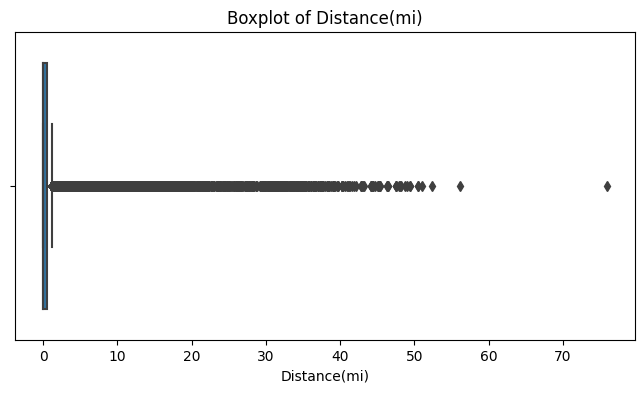

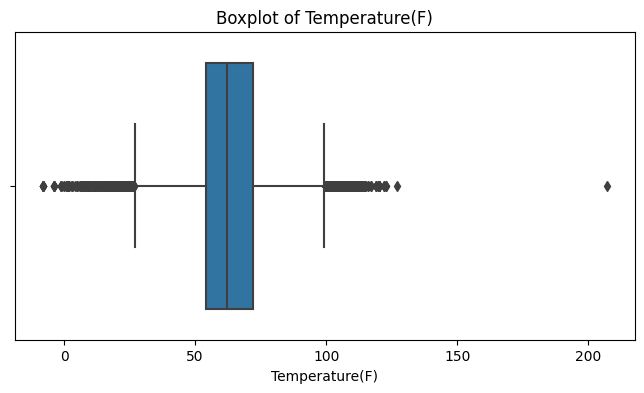

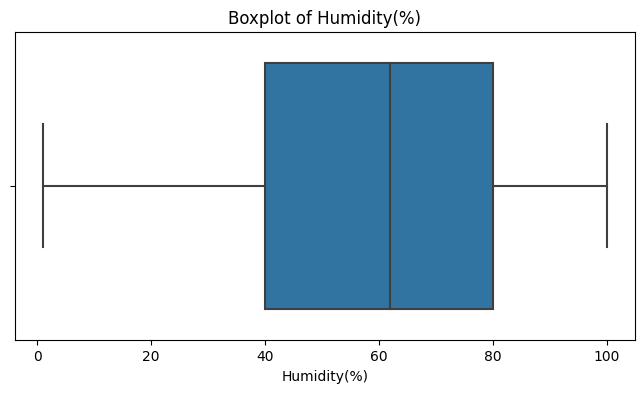

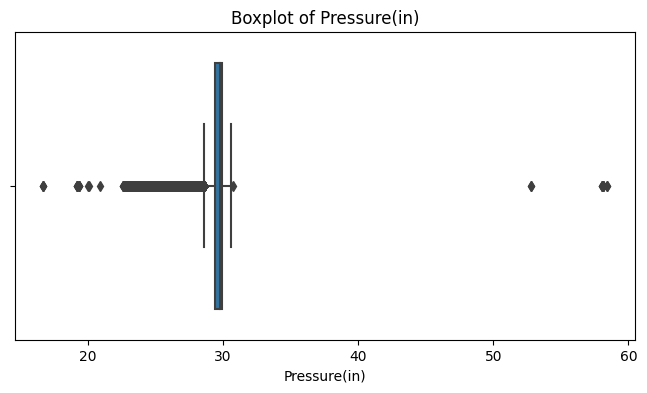

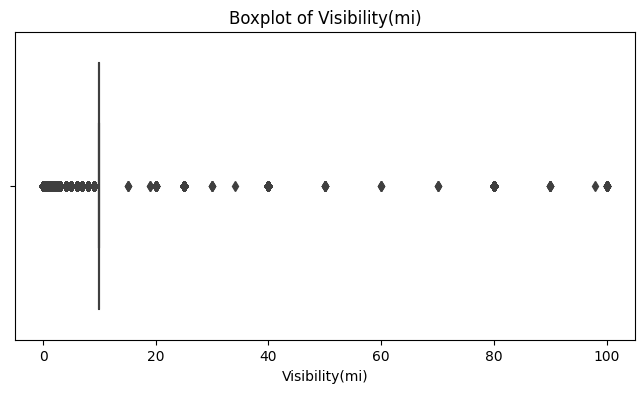

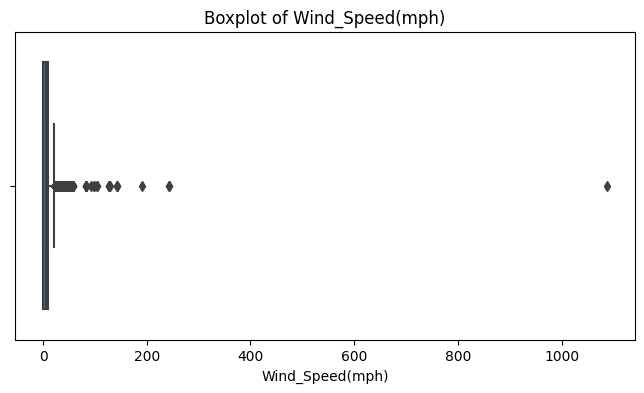

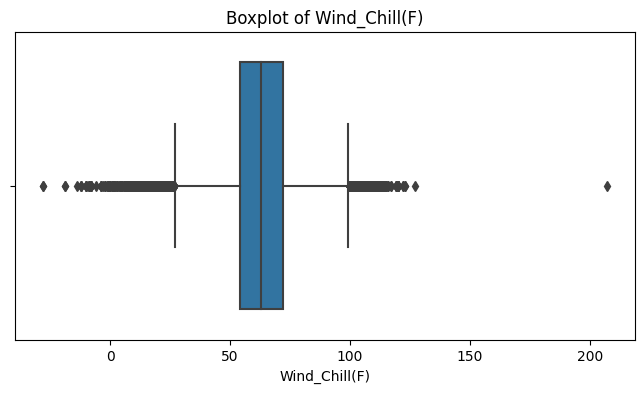

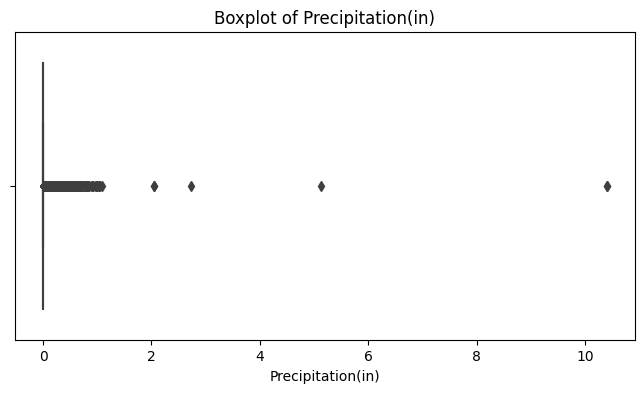

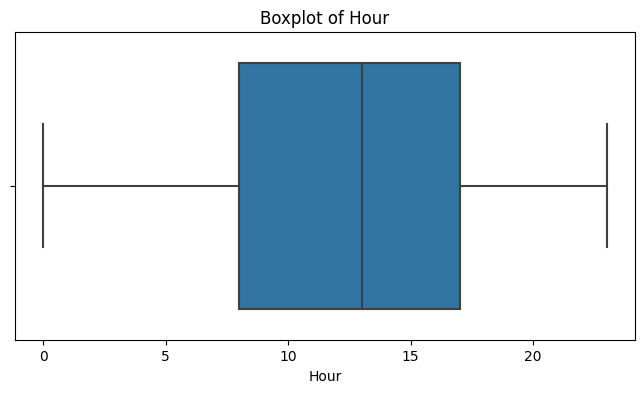

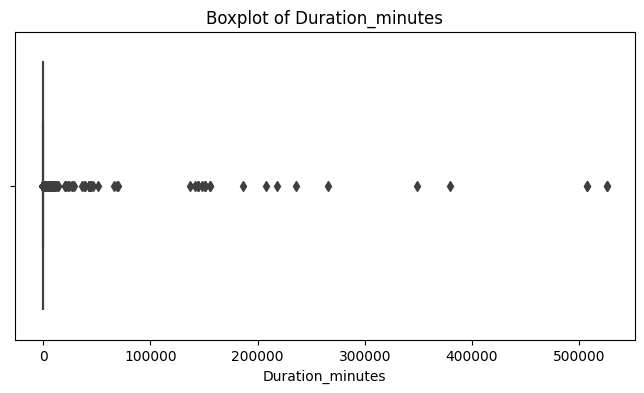

,Severity,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),day_of_week,Hour,Duration_minutes,Month,Is_Holiday,Is_Rush_Hour,accident_density
count,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000,980125.000000
mean,2.098397,0.539264,63.173163,63.056511,59.083077,29.515937,8.992686,6.095763,0.004134,2.835032,12.359919,121.683419,6.625589,0.030199,0.383923,97873.658777
std,0.344728,1.414149,13.712230,14.115127,24.410542,0.859444,2.717702,5.475986,0.030002,1.897738,5.853096,1389.254402,3.743528,0.171135,0.486340,104080.308792
min,1.000000,0.000000,-8.000000,-28.000000,1.000000,16.710000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,143.000000
25%,2.000000,0.000000,54.000000,54.000000,40.000000,29.420000,10.000000,0.000000,0.000000,1.000000,8.000000,44.766667,3.000000,0.000000,0.000000,15716.000000
50%,2.000000,0.049000,62.000000,62.825993,62.000000,29.800000,10.000000,6.000000,0.000000,3.000000,13.000000,79.416667,7.000000,0.000000,0.000000,54183.000000
75%,2.000000,0.498000,72.000000,72.000000,80.000000,29.940000,10.000000,9.000000,0.000000,4.000000,17.000000,131.750000,10.000000,0.000000,1.000000,265466.000000
max,4.000000,75.879997,207.000000,207.000000,100.000000,58.390000,100.000000,1087.000000,10.400000,6.000000,23.000000,525599.983333,12.000000,1.000000,1.000000,265466.000000


In [31]:
# Dealing with outliers is crucial for a clean and reliable dataset
# Outliers can lead to poor generalization, reducing model precision and overall accuracy.
# CA_Accidents has two types of outliers: natural(exterme but valid values) and data collection error(ex:impossible weather conditions)
# We will remove the outliers caused by data collection error, and retain natural outliers as is, since they may hold valuable information.
numeric_cols = ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                'Visibility(mi)', 'Wind_Speed(mph)','Wind_Chill(F)', 'Precipitation(in)', 'Hour', 'Duration_minutes']

# Ploting Boxplots to visualize outliers
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=filtered_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    
# Dataset Basic Statictis 
filtered_df.describe() 

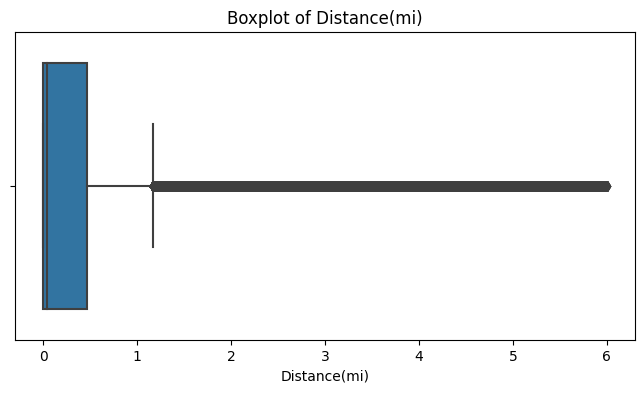

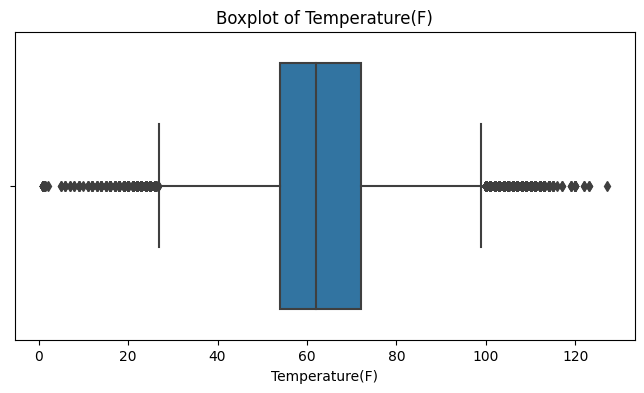

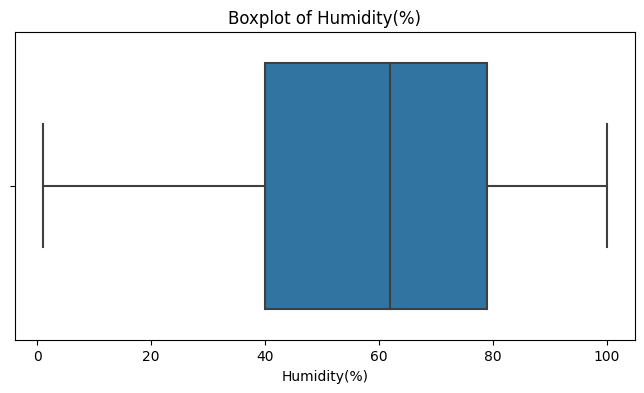

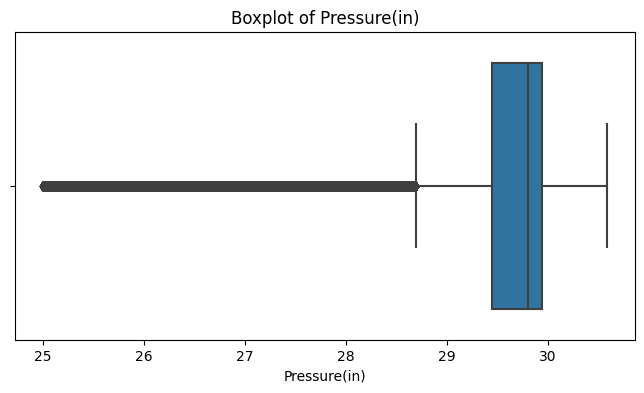

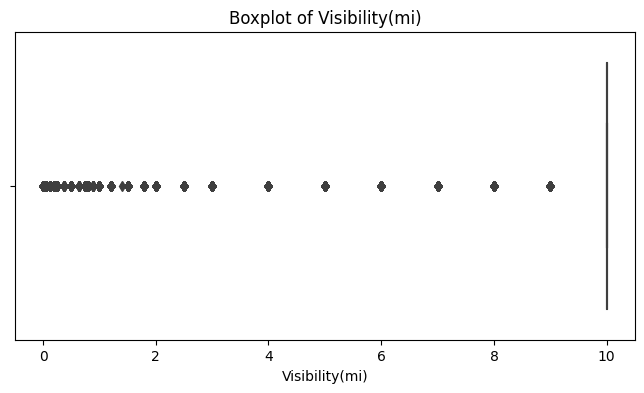

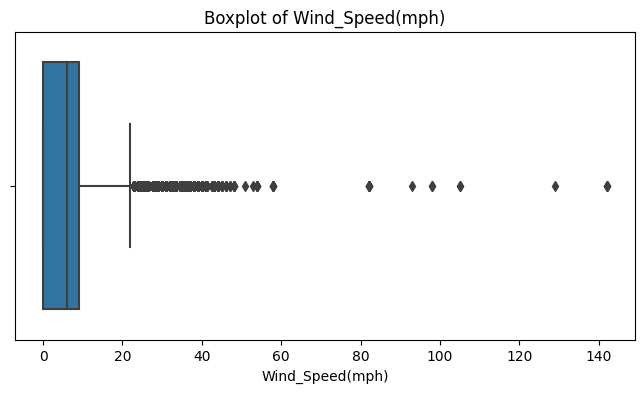

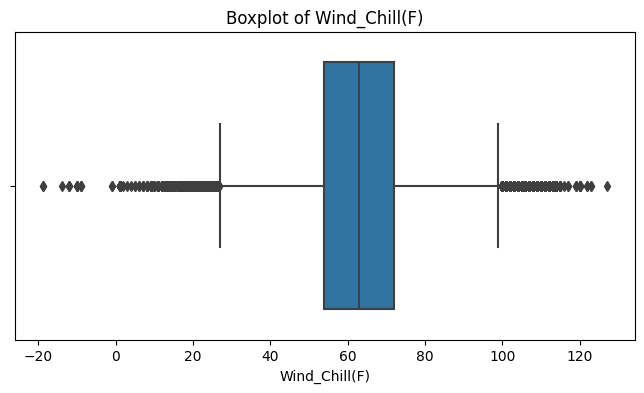

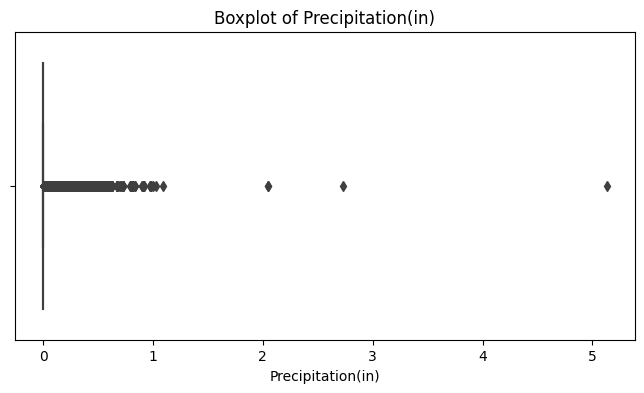

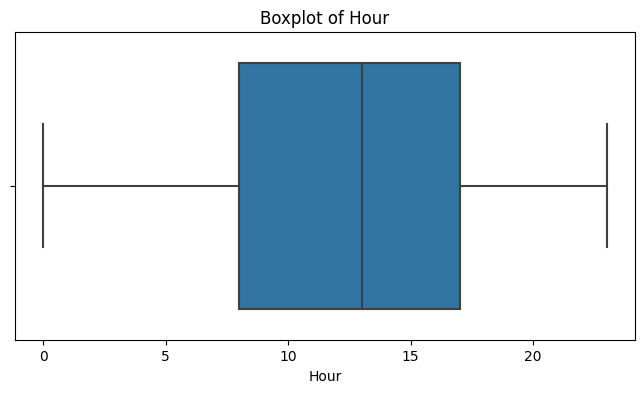

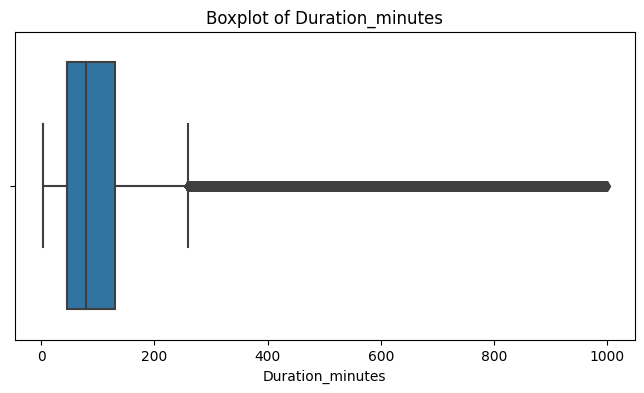

,Severity,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),day_of_week,Hour,Duration_minutes,Month,Is_Holiday,Is_Rush_Hour,accident_density
count,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000,957018.000000
mean,2.099179,0.427438,63.336023,63.251349,59.086018,29.559455,8.962617,6.081019,0.004086,2.835613,12.370561,108.165578,6.623480,0.030118,0.385657,98276.744169
std,0.345108,0.852321,13.499308,13.831255,24.361008,0.706305,2.262793,5.331431,0.025937,1.898680,5.862466,108.228918,3.740831,0.170911,0.486750,104032.904176
min,1.000000,0.000000,1.000000,-18.800000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,143.000000
25%,2.000000,0.000000,54.000000,54.000000,40.000000,29.440000,10.000000,0.000000,0.000000,1.000000,8.000000,44.716667,3.000000,0.000000,0.000000,22071.000000
50%,2.000000,0.043000,62.000000,62.825993,62.000000,29.800000,10.000000,6.000000,0.000000,3.000000,13.000000,79.033333,7.000000,0.000000,0.000000,54183.000000
75%,2.000000,0.467000,72.000000,72.000000,79.000000,29.940000,10.000000,9.000000,0.000000,4.000000,17.000000,130.616667,10.000000,0.000000,1.000000,265466.000000
max,4.000000,5.999000,127.000000,127.000000,100.000000,30.580000,10.000000,142.000000,5.130000,6.000000,23.000000,999.500000,12.000000,1.000000,1.000000,265466.000000


In [32]:
# Removing outliers
filtered_df = filtered_df[filtered_df['Wind_Chill(F)'] < 140]
filtered_df = filtered_df[filtered_df['Temperature(F)'] < 140]
filtered_df = filtered_df[filtered_df['Wind_Speed(mph)'] < 200]
filtered_df = filtered_df[(filtered_df['Pressure(in)'] >= 25) & (filtered_df['Pressure(in)'] <= 40)]
filtered_df = filtered_df[filtered_df['Distance(mi)'] < 6]
filtered_df = filtered_df[filtered_df['Precipitation(in)'] < 6]
filtered_df = filtered_df[filtered_df['Duration_minutes'] < 1000]
filtered_df = filtered_df[filtered_df['Visibility(mi)'] < 11]
filtered_df = filtered_df[filtered_df['Wind_Speed(mph)'] < 150]


# Ploting Boxplots to visualize outliers
numeric_cols = ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                'Visibility(mi)', 'Wind_Speed(mph)','Wind_Chill(F)', 'Precipitation(in)', 'Hour', 
               'Duration_minutes']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=filtered_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    
    
# Dataset Basic Statictis 
filtered_df.describe() 

##  Grouping Data Categorical Encoding/ One Hot encoding 

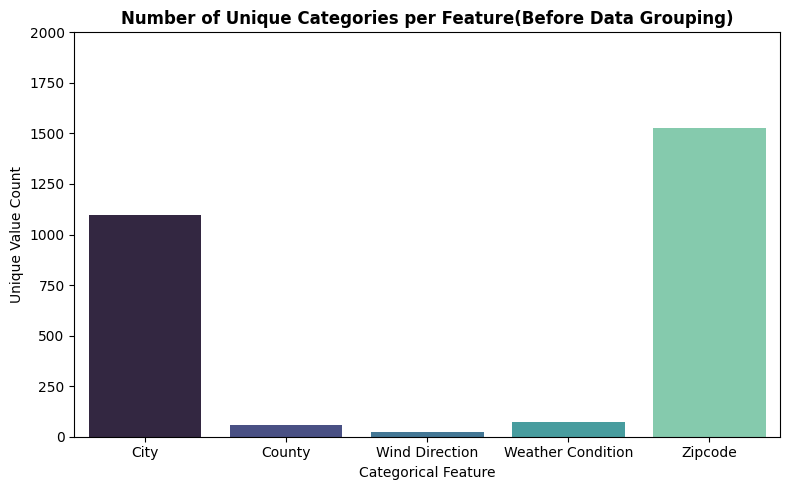

In [33]:
# Plot for Presentation and Report 
# Dictionary of column names and their unique value counts
unique_counts = {
    'City': filtered_df['City'].nunique(),
    'County': filtered_df['County'].nunique(),
    'Wind Direction': filtered_df['Wind_Direction'].nunique(),
    'Weather Condition': filtered_df['Weather_Condition'].nunique(),
    'Zipcode': filtered_df['Zipcode'].nunique()
}

# Convert to DataFrame for plotting
unique_df = pd.DataFrame(list(unique_counts.items()), columns=['Feature', 'Unique Values'])

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=unique_df, x='Feature', y='Unique Values', palette='mako')
plt.title("Number of Unique Categories per Feature(Before Data Grouping)", fontweight='bold')
plt.ylabel("Unique Value Count")
plt.xlabel("Categorical Feature")
plt.tight_layout()
plt.ylim(0, 2000) 
plt.show()


In [34]:
# The raw city column as more than 1000 citys,some of citys have limited accident data.
# So grouping and using threshold the best option considering our skill level.

# Looking for the optimal threshold value
city_counts = filtered_df['City'].value_counts()
for t in [1000,2500,5000,10000]:
    print(f"Threshold {t}: Cities kept = {(city_counts >= t).sum()}")

#Get frequency of each city
city_counts = filtered_df['City'].value_counts()

# Setting the threshold as 10000
threshold = 10000
common_cities = city_counts[city_counts >= threshold].index

# Replace rare cities with "Other"
filtered_df['City'] = filtered_df['City'].apply(lambda x: x if x in common_cities else 'Other')

# Confirm City unique
print(f"Unique Cities After Grouping:{filtered_df['City'].nunique()}")

# Final City Column
filtered_df['City'].value_counts()

Threshold 1000: Cities kept = 202
Threshold 2500: Cities kept = 82
Threshold 5000: Cities kept = 26
Threshold 10000: Cities kept = 13
Unique Cities After Grouping:14


City
Other             673357
Los Angeles        88984
San Diego          33515
Sacramento         28978
Riverside          16053
Bakersfield        15792
Oakland            14165
San Bernardino     13933
Fresno             12678
Anaheim            12616
San Jose           12299
Ontario            12110
Long Beach         11911
San Francisco      10627
Name: count, dtype: int64

In [35]:
# The raw Zipcode column as more than 1525 Zipcode
# We need to Zipcode column into a manageble column with few unique zipcode
# 1525 Zipcode after hot one enconding will become 1525 extra columns, which is awfull for training

# Zipcode - Keeping only the first three digits
print(f"Unique Zipcodes Before Grouping:{filtered_df['Zipcode'].nunique()}")
filtered_df['Zipcode_Group'] = filtered_df['Zipcode'].astype(str).str[:3]
print(f"Unique Zipcodes After Grouping:{filtered_df['Zipcode_Group'].nunique()}")

# Use zipcode when using XBG/Random forest, and use Zipcode_Group for SVM
filtered_df.shape

Unique Zipcodes Before Grouping:1525
Unique Zipcodes After Grouping:57


(957018, 22)

In [36]:
# Same reasons and logic used  from City grouping 

Weather_Condition_counts = filtered_df['Weather_Condition'].value_counts()
for t in [500, 750, 1000]:
    print(f"Threshold {t}: Weather_Condition kept = {(Weather_Condition_counts >= t).sum()}")
     
# Setting the threshold as 1000
threshold = 1000 
common_weather = Weather_Condition_counts[Weather_Condition_counts >= threshold].index

# Replace rare Weather Conditions with "Other"
filtered_df["Weather_Condition"] = filtered_df["Weather_Condition"].apply(
    lambda x: x if x in common_weather else "Other"
)

# Confirm unique Weather Conditions unique
print(f"Unique Weather Conditions After Grouping:{filtered_df['Weather_Condition'].nunique()}")


Threshold 500: Weather_Condition kept = 19
Threshold 750: Weather_Condition kept = 16
Threshold 1000: Weather_Condition kept = 15
Unique Weather Conditions After Grouping:16


In [37]:
# Keeping only top 20 Counties and marking the remaining as other
top20 = filtered_df['County'].value_counts().head(20).index
filtered_df['County'] = filtered_df['County'].apply(lambda x: x if x in top20 else 'Other')

# Doing the Zipcode_Group
top30 = filtered_df['Zipcode_Group'].value_counts().head(30).index
filtered_df['Zipcode_Group'] = filtered_df['Zipcode_Group'].apply(lambda x: x if x in top30 else 'Other')

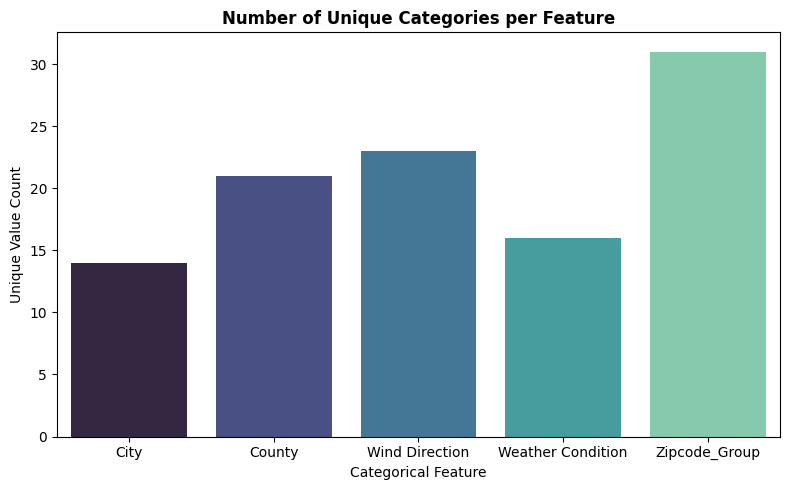

In [38]:
# Plot for Presentation and Report
# Dictionary of column names and their unique value counts
unique_counts = {
    'City': filtered_df['City'].nunique(),
    'County': filtered_df['County'].nunique(),
    'Wind Direction': filtered_df['Wind_Direction'].nunique(),
    'Weather Condition': filtered_df['Weather_Condition'].nunique(),
    'Zipcode_Group': filtered_df['Zipcode_Group'].nunique()
}

# Convert to DataFrame for plotting
unique_df = pd.DataFrame(list(unique_counts.items()), columns=['Feature', 'Unique Values'])

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=unique_df, x='Feature', y='Unique Values', palette='mako')
plt.title("Number of Unique Categories per Feature", fontweight='bold')
plt.ylabel("Unique Value Count")
plt.xlabel("Categorical Feature")
plt.tight_layout()
plt.show()


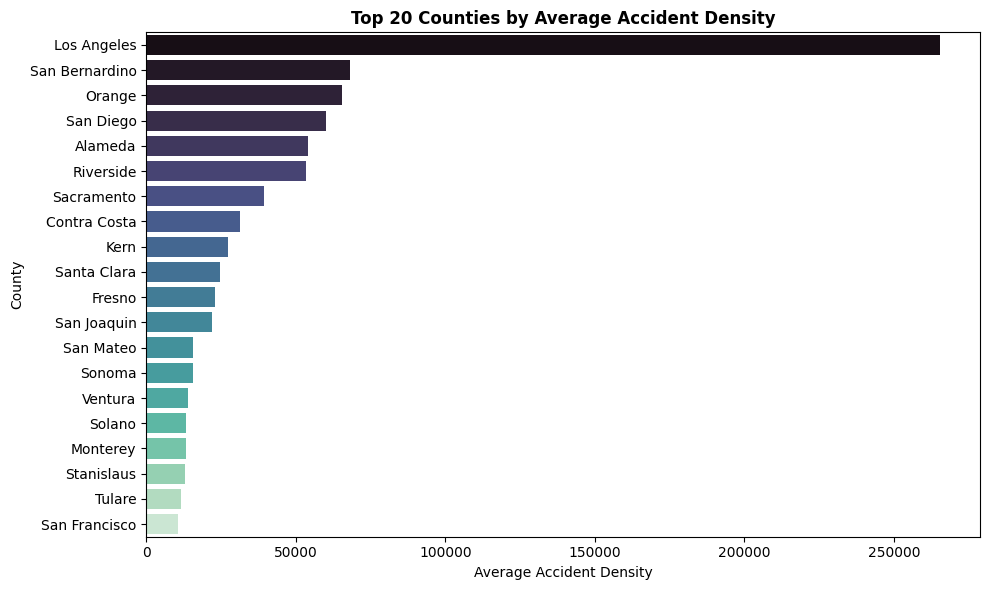

In [39]:
# Plot for Presentation and Report
# Group by County
county_density = (
    filtered_df.groupby('County')['accident_density']
    .max()  # or use .max() if you prefer
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=county_density, x='accident_density', y='County', palette='mako')
plt.title("Top 20 Counties by Average Accident Density", fontweight='bold')
plt.xlabel("Average Accident Density")
plt.ylabel("County")
plt.tight_layout()
plt.show()


In [40]:
# Final Analysis 
print(f"City: {filtered_df['City'].nunique()}")
print(f"County: {filtered_df['County'].nunique()}")
print(f"Wind_Direction: {filtered_df['Wind_Direction'].nunique()}")
print(f"Weather_Condition: {filtered_df['Weather_Condition'].nunique()}")
print(f"Zipcode_Group: {filtered_df['Zipcode_Group'].nunique()}")
filtered_df.dtypes

City: 14
County: 21
Wind_Direction: 23
Weather_Condition: 16
Zipcode_Group: 31


Severity               int64
Distance(mi)         float64
City                  object
County                object
Zipcode               object
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Direction        object
Wind_Speed(mph)      float64
Precipitation(in)    float64
Weather_Condition     object
day_of_week            int32
Hour                   int64
Duration_minutes     float64
Month                  int32
Is_Holiday             int64
Is_Rush_Hour           int64
accident_density       int64
Zipcode_Group         object
dtype: object

In [41]:
#Peforming One hot encoding
filtered_df = pd.get_dummies(filtered_df, columns=['City',"County",'Wind_Direction',"Weather_Condition","Zipcode_Group"])

# Final Shape
filtered_df.shape

(957018, 122)

In [42]:
filtered_df.head(3)

,Severity,Distance(mi),Zipcode,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),...,Zipcode_Group_946,Zipcode_Group_950,Zipcode_Group_951,Zipcode_Group_952,Zipcode_Group_953,Zipcode_Group_954,Zipcode_Group_956,Zipcode_Group_958,Zipcode_Group_959,Zipcode_Group_Other
230,3,0.0,94534,55.9,62.825993,80.0,29.96,10.0,9.2,0.0,...,False,False,False,False,False,False,False,False,False,False
240,3,0.0,94534,54.0,62.825993,83.0,29.98,10.0,5.8,0.0,...,False,False,False,False,False,False,False,False,False,False
919,3,0.0,94541,60.1,62.825993,67.0,30.04,10.0,11.5,0.0,...,False,False,False,False,False,False,False,False,False,False


In [43]:
# Memory usage before downcasting
before = filtered_df.memory_usage(deep=True).sum() /  1048576   # Convert to MB
print(f"Memory usage before downcasting: {before:.2f} MB")
# Downcasting for memory management
filtered_df["Severity"] = filtered_df["Severity"].astype("int8")
filtered_df["Distance(mi)"] = pd.to_numeric(filtered_df["Distance(mi)"], downcast="float")
filtered_df["Temperature(F)"] = pd.to_numeric(filtered_df["Temperature(F)"], downcast="float")
filtered_df["Wind_Chill(F)"] = pd.to_numeric(filtered_df["Wind_Chill(F)"], downcast="float")
filtered_df["Humidity(%)"] = pd.to_numeric(filtered_df["Humidity(%)"], downcast="float")
filtered_df["Pressure(in)"] = pd.to_numeric(filtered_df["Pressure(in)"], downcast="float")
filtered_df["Visibility(mi)"] = pd.to_numeric(filtered_df["Visibility(mi)"], downcast="float")
filtered_df["Wind_Speed(mph)"] = pd.to_numeric(filtered_df["Wind_Speed(mph)"], downcast="float")
filtered_df["Precipitation(in)"] = pd.to_numeric(filtered_df["Precipitation(in)"], downcast="float")
filtered_df["Duration_minutes"] = pd.to_numeric(filtered_df["Duration_minutes"], downcast="float")

# Memory usage after downcasting
after = filtered_df.memory_usage(deep=True).sum() / 1048576
print(f"Memory usage after downcasting: {after:.2f} MB")
memory_saved = (before -after)/before * 100
print(f"Memory usage reduced by: {memory_saved:.2f}%")

bool_cols = filtered_df.select_dtypes(include='bool').columns
filtered_df[bool_cols] = filtered_df[bool_cols].astype("int8")


for col in ["day_of_week", "Hour", "Month", "Is_Holiday", "Is_Rush_Hour"]:
    filtered_df[col] = filtered_df[col].astype("int8")



Memory usage before downcasting: 269.24 MB
Memory usage after downcasting: 230.00 MB
Memory usage reduced by: 14.58%


In [44]:
filtered_df.dtypes

Severity                  int8
Distance(mi)           float32
Zipcode                 object
Temperature(F)         float32
Wind_Chill(F)          float32
                        ...   
Zipcode_Group_954         int8
Zipcode_Group_956         int8
Zipcode_Group_958         int8
Zipcode_Group_959         int8
Zipcode_Group_Other       int8
Length: 122, dtype: object

## Standardization 

In [45]:
# Import All the Dependencies
from sklearn.preprocessing import StandardScaler

# Since we are clustering normalization is critical for perfect clusters
# Why Standardization over normalization
# It handles outliers better.
# It makes the mean around 0 with a standard deviation of 1.
# Clustering algorithms like KMeans use distances, so all features need to be on the same scale.

# Only Standardization numerical columns 
cols_to_standardize =['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                'Visibility(mi)', 'Wind_Speed(mph)','Wind_Chill(F)', 'Precipitation(in)', 'Hour', 
              'Duration_minutes', 'accident_density']

# Standardize numerical columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(filtered_df[cols_to_standardize])

# Make it back to a df
scaled_df = pd.DataFrame(scaled_data, columns=cols_to_standardize)

# Combine Standardize numerical df with Categorical df
standardize_df = pd.concat([scaled_df, filtered_df.drop(columns=cols_to_standardize).reset_index(drop=True)], axis=1)

# Testing Flag
print(standardize_df.shape)
standardize_df.head(5)

(957018, 122)


,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Wind_Chill(F),Precipitation(in),Hour,Duration_minutes,...,Zipcode_Group_946,Zipcode_Group_950,Zipcode_Group_951,Zipcode_Group_952,Zipcode_Group_953,Zipcode_Group_954,Zipcode_Group_956,Zipcode_Group_958,Zipcode_Group_959,Zipcode_Group_Other
0,-0.501499,-0.550845,0.858503,0.567098,0.458453,0.585018,-0.030753,-0.157538,1.813135,-0.722225,...,0,0,0,0,0,0,0,0,0,0
1,-0.501499,-0.691593,0.981650,0.595415,0.458453,-0.052710,-0.030753,-0.157538,-1.598400,-0.445035,...,0,0,0,0,0,0,0,0,0,0
2,-0.501499,-0.239718,0.324863,0.680366,0.458453,1.016422,-0.030753,-0.157538,-0.404363,-0.575468,...,0,0,0,0,0,0,0,0,0,0
3,-0.501499,0.782557,-0.537171,0.666208,0.458453,0.378694,-0.030753,-0.157538,-0.233786,-0.722225,...,0,0,0,0,0,0,0,0,0,0
4,-0.501499,0.782557,-0.537171,0.666208,0.458453,0.378694,-0.030753,-0.157538,-0.233786,-0.722225,...,0,0,0,0,0,0,0,0,0,0


# Clustering 

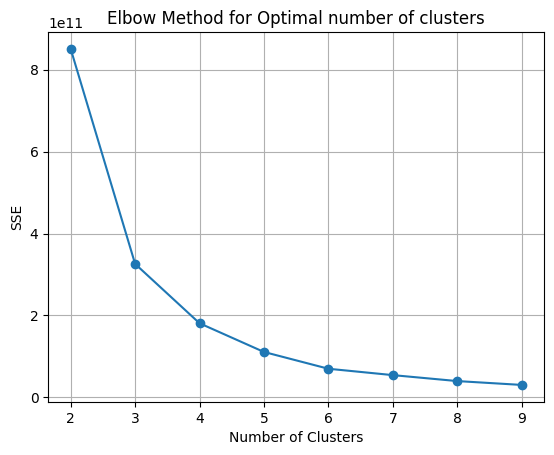

In [46]:
#Import All Dependencies 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Elbow Method to decide number of Cluster
# sse - Sum of Squared errors
sse = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(standardize_df.drop("Severity", axis=1))
    sse.append(km.inertia_)

plt.plot(range(2, 10), sse, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method for Optimal number of clusters")
plt.grid(True)
plt.show()

In [47]:
# Clustering into three clusters using  KMeans
standardize_df = standardize_df.copy() 
km = KMeans(n_clusters=3)
standardize_df['Cluster'] = km.fit_predict(standardize_df.drop("Severity",axis =1))
print(standardize_df['Cluster'].value_counts())

# Evaluating the quality of clusters  
sample_df = standardize_df.sample(n=10000, random_state=42)
score = silhouette_score(sample_df.drop(columns='Cluster'), sample_df['Cluster'])
print(f"Silhouette Score: {score:.3f}")


Cluster
2    386700
0    349418
1    220900
Name: count, dtype: int64
Silhouette Score: 0.644


In [48]:
# Deciding what cluster should be low,medium,high risk 
print("Severity")
print(standardize_df.groupby('Cluster')['Severity'].mean())
print("\n Accident Duration")
print(standardize_df.groupby('Cluster')['Duration_minutes'].mean())
print("\n  Accident Density")
print(standardize_df.groupby('Cluster')['accident_density'].mean())

# Cluster 1 - High Risk
# Cluster 0 - Midium Risk
# CLuster 2 - Low Risk

Severity
Cluster
0    2.079235
1    2.157103
2    2.084112
Name: Severity, dtype: float64

 Accident Duration
Cluster
0   -0.043897
1    0.071848
2   -0.001377
Name: Duration_minutes, dtype: float64

  Accident Density
Cluster
0   -0.721191
1    1.533568
2   -0.224381
Name: accident_density, dtype: float64


# Sampling

In [49]:
# Import SMOTE
from  imblearn.over_sampling import SMOTE,  ADASYN

# Oversample since the dataset is unbalanced
# Defining X and y 
X = standardize_df.drop("Cluster",axis =1)
y =standardize_df["Cluster"]

sampler = SMOTE(random_state=42)
X_resampled, y_resampled = sampler.fit_resample(X, y)

X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_df = pd.Series(y_resampled, name ='Cluster')
    
final_df = pd.concat([X_resampled_df,y_resampled_df],axis=1)

print(final_df['Cluster'].value_counts())


# Evaluating the quality of clusters  
sample_df = final_df.sample(n=10000, random_state=42)
score = silhouette_score(sample_df.drop(columns='Cluster'), sample_df['Cluster'])
print(f"Silhouette Score: {score:.3f}")
final_df.shape

Cluster
0    386700
2    386700
1    386700
Name: count, dtype: int64
Silhouette Score: 0.648


(1160100, 123)

In [264]:
final_df.head(3)

,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Wind_Chill(F),Precipitation(in),Hour,Duration_minutes,accident_density,Severity,Zipcode,day_of_week,Month,Is_Holiday,Is_Rush_Hour,City_Anaheim,City_Bakersfield,City_Fresno,City_Long Beach,City_Los Angeles,City_Oakland,City_Ontario,City_Other,City_Riverside,City_Sacramento,City_San Bernardino,City_San Diego,City_San Francisco,City_San Jose,County_Alameda,County_Contra Costa,County_Fresno,County_Kern,County_Los Angeles,County_Monterey,County_Orange,County_Other,County_Riverside,County_Sacramento,County_San Bernardino,County_San Diego,County_San Francisco,County_San Joaquin,County_San Mateo,County_Santa Clara,County_Solano,County_Sonoma,County_Stanislaus,County_Tulare,County_Ventura,Wind_Direction_CALM,Wind_Direction_E,Wind_Direction_ENE,Wind_Direction_ESE,Wind_Direction_East,Wind_Direction_N,Wind_Direction_NE,Wind_Direction_NNE,Wind_Direction_NNW,Wind_Direction_NW,Wind_Direction_North,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SSE,Wind_Direction_SSW,Wind_Direction_SW,Wind_Direction_South,Wind_Direction_VAR,Wind_Direction_Variable,Wind_Direction_W,Wind_Direction_WNW,Wind_Direction_WSW,Wind_Direction_West,Weather_Condition_Cloudy,Weather_Condition_Cloudy / Windy,Weather_Condition_Fair,Weather_Condition_Fair / Windy,Weather_Condition_Fog,Weather_Condition_Haze,Weather_Condition_Heavy Rain,Weather_Condition_Light Rain,Weather_Condition_Mostly Cloudy,Weather_Condition_Mostly Cloudy / Windy,Weather_Condition_Other,Weather_Condition_Overcast,Weather_Condition_Partly Cloudy,Weather_Condition_Partly Cloudy / Windy,Weather_Condition_Rain,Weather_Condition_Smoke,Zipcode_Group_900,Zipcode_Group_902,Zipcode_Group_906,Zipcode_Group_907,Zipcode_Group_913,Zipcode_Group_917,Zipcode_Group_920,Zipcode_Group_921,Zipcode_Group_923,Zipcode_Group_924,Zipcode_Group_925,Zipcode_Group_926,Zipcode_Group_928,Zipcode_Group_930,Zipcode_Group_932,Zipcode_Group_933,Zipcode_Group_935,Zipcode_Group_936,Zipcode_Group_937,Zipcode_Group_940,Zipcode_Group_945,Zipcode_Group_946,Zipcode_Group_950,Zipcode_Group_951,Zipcode_Group_952,Zipcode_Group_953,Zipcode_Group_954,Zipcode_Group_956,Zipcode_Group_958,Zipcode_Group_959,Zipcode_Group_Other,Cluster
0,-0.501499,-0.550845,0.858503,0.567098,0.458453,0.585018,-0.030753,-0.157538,1.813135,-0.722225,-0.817653,3,94534.0,2,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
1,-0.501499,-0.691593,0.981650,0.595415,0.458453,-0.052710,-0.030753,-0.157538,-1.598400,-0.445035,-0.817653,3,94534.0,3,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
2,-0.501499,-0.239718,0.324863,0.680366,0.458453,1.016422,-0.030753,-0.157538,-0.404363,-0.575468,-0.423844,3,94541.0,2,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2


In [260]:
# Storing Data for Trainning 
final_df.to_csv("TripSafe_cleaned_Data.csv")

# Save 100K samples
subset_TripSafe_cleaned_Data =final_df.sample(n = 100000, random_state =42)
subset_TripSafe_cleaned_Data.to_csv("sample_TripSafe_cleaned_Data.csv")